# Customer Churn Analysis & Prediction

## Project Overview

Customer churn occurs when a customer stops using a company's service, which can lead to revenue loss and affect business growth.

This project analyzes the **Telco Customer Churn dataset** to understand churn patterns and build a **Random Forest classification model** to predict whether a customer is likely to churn.

### Objectives

- Understand the customer churn dataset
- Perform data cleaning and preprocessing
- Analyze churn distribution
- Convert categorical variables into numerical features
- Train a Random Forest classification model
- Evaluate model performance using multiple metrics
- Identify important features associated with model predictions
- Derive practical business insights

## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. Load Dataset

The Telco Customer Churn dataset is uploaded and loaded into a Pandas DataFrame for analysis. The upload method uses the actual filename selected by the user, so the notebook is not dependent on a fixed local filename.

In [54]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

dataset = pd.read_csv(file_name)

dataset.head()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (2).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Understand the Dataset

Before building the model, the dataset is inspected to understand its size, structure, data types, missing values, duplicate records, and numerical statistics.

### Dataset Shape

In [55]:
print("Dataset shape:", dataset.shape)

Dataset shape: (7043, 21)


### Dataset Information

In [56]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Missing Values

In [57]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Duplicate Records

In [58]:
print("Duplicate records:", dataset.duplicated().sum())

Duplicate records: 0


### Statistical Summary

In [59]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Churn Analysis

The target variable, **Churn**, is analyzed to understand how many customers stayed with the service and how many left.

An end-to-end machine learning project using Python to analyze customer churn patterns and predict customers who are at risk of leaving a telecom service.

### Churn Counts

In [60]:
churn_counts = dataset["Churn"].value_counts()
churn_counts

,count
Churn,
No,5174
Yes,1869


### Churn Percentage

In [61]:
churn_percentage = dataset["Churn"].value_counts(normalize=True) * 100
churn_percentage.round(2)

,proportion
Churn,
No,73.46
Yes,26.54


### Churn Distribution

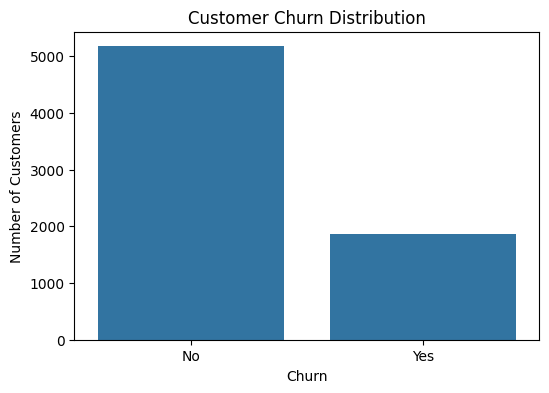

In [62]:
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Churn Analysis Summary

Approximately **26.5%** of customers have churned, while **73.5%** have remained with the company. Churn is therefore the minority class, which is important when interpreting classification metrics, especially recall for churned customers.

## 5. Data Preprocessing

The dataset is prepared for machine learning by converting `TotalCharges` to numeric format, handling missing values, removing the customer identifier, encoding the target variable, and converting categorical features into numerical dummy variables.

### Convert Total Charges to Numeric

In [63]:
dataset["TotalCharges"] = pd.to_numeric(
    dataset["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:", dataset["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion: 11


### Handle Missing Values

The numeric conversion creates **11 missing values** in `TotalCharges`. These values are replaced with 0 because they correspond to customers with very short or zero tenure in the dataset.

In [64]:
dataset["TotalCharges"] = dataset["TotalCharges"].fillna(0)

print("Remaining missing TotalCharges:", dataset["TotalCharges"].isnull().sum())

Remaining missing TotalCharges: 0


### Remove Duplicate Records

Duplicate rows are removed if any are present. For this dataset, the duplicate count is expected to be zero.

In [65]:
duplicate_count = dataset.duplicated().sum()
print("Duplicate records before removal:", duplicate_count)

if duplicate_count > 0:
    dataset = dataset.drop_duplicates()

print("Dataset shape after duplicate handling:", dataset.shape)

Duplicate records before removal: 0
Dataset shape after duplicate handling: (7043, 21)


### Remove Customer Identifier

`customerID` is removed because it is a unique identifier and does not provide meaningful predictive information for churn.

In [66]:
dataset = dataset.drop("customerID", axis=1)

dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Encode Churn Target

The target variable is converted into binary numerical values:

- `No` → 0
- `Yes` → 1

In [67]:
dataset["Churn"] = dataset["Churn"].map({"No": 0, "Yes": 1})

dataset["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


### Encode Categorical Features

The remaining categorical variables are converted into numerical dummy variables using one-hot encoding. `drop_first=True` reduces redundant dummy columns.

In [68]:
categorical_cols = dataset.select_dtypes(include="object").columns

dataset = pd.get_dummies(
    dataset,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Preprocessed dataset shape:", dataset.shape)
dataset.head()

Preprocessed dataset shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 6. Prepare Data for Modeling

The preprocessed data is separated into predictor variables (`X`) and the target variable (`y`), followed by a stratified train-test split.

**Note:** Random Forest is a tree-based algorithm and does not require feature scaling, so StandardScaler is not necessary for this model.

### Separate Features and Target

In [69]:
X = dataset.drop("Churn", axis=1)
y = dataset["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


### Train-Test Split

80% of the data is used for training and 20% for testing. Stratification preserves the churn/non-churn class proportion in both sets.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 30)
Testing set: (1409, 30)


## 7. Model Training

A **Random Forest Classifier** is trained to predict customer churn. The model combines multiple decision trees to produce a more robust classification model.

In [71]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Generate Predictions

In [72]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 8. Model Evaluation

The model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, a classification report, and a confusion matrix. Multiple metrics are used because churn is the minority class.

### Performance Metrics

In [73]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

Accuracy : 78.50%
Precision: 0.62
Recall   : 0.50
F1-Score : 0.55
ROC-AUC  : 0.825


### Classification Report

In [74]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



### Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified customers in the non-churn and churn classes.

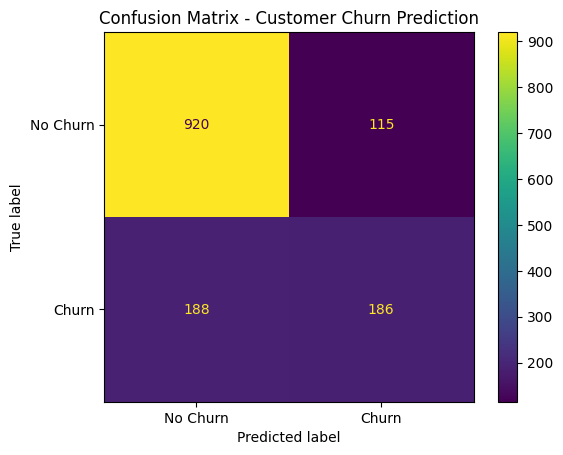

In [75]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

### Performance Summary

In [76]:
performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

performance["Score (%)"] = performance["Score"] * 100
performance

,Metric,Score,Score (%)
0,Accuracy,0.784954,78.495387
1,Precision,0.617940,61.794020
2,Recall,0.497326,49.732620
3,F1-Score,0.551111,55.111111
4,ROC-AUC,0.825331,82.533132


## 9. Feature Importance

Random Forest provides feature importance scores that indicate which variables contributed most to the model's predictions. These scores describe model behavior and should not be interpreted as proof of causation.

## 10. Feature Importance

Feature importance is used to identify the variables that contribute most to the Random Forest model's predictions. These results help highlight the customer characteristics most associated with the model's churn predictions.

In [77]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 important features:")
display(feature_importance.head(10).to_frame("Importance"))

Top 10 important features:


,Importance
TotalCharges,0.191149
tenure,0.174795
MonthlyCharges,0.169026
PaymentMethod_Electronic check,0.039095
InternetService_Fiber optic,0.037259
Contract_Two year,0.029864
OnlineSecurity_Yes,0.029774
gender_Male,0.028501
PaperlessBilling_Yes,0.025097
TechSupport_Yes,0.023192


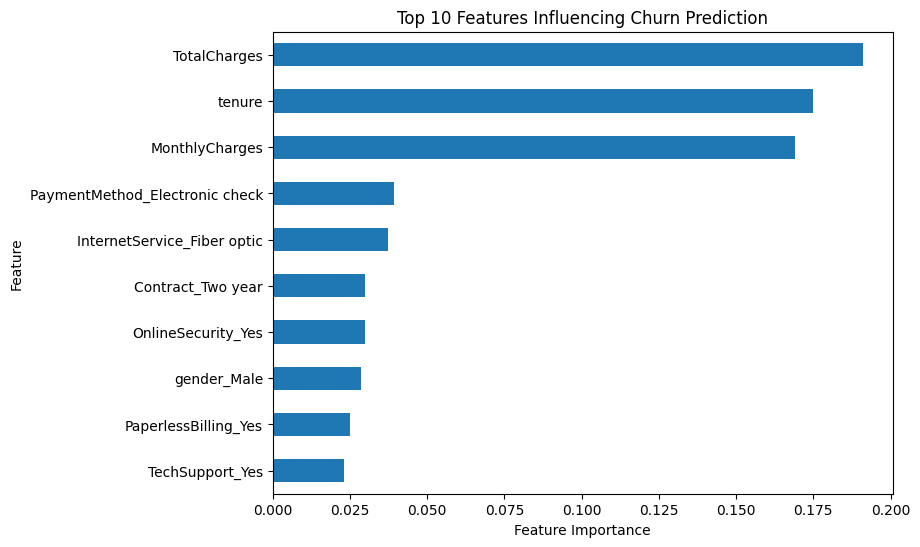

In [78]:
plt.figure(figsize=(8, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

### Interpretation

The feature-importance results indicate which customer attributes have the greatest influence on the model's predictions. These variables can be considered important signals when identifying customers who may be at higher risk of churn.

Feature importance shows model association and should not be interpreted as proof of a causal relationship with customer churn.

## 11. Key Findings

The analysis produced the following key findings:

- Approximately 26.5% of customers in the dataset have churned, while 73.5% have remained with the service.
- The Random Forest model achieved an accuracy of 78.50% on the test dataset.
- The model achieved a ROC-AUC score of 0.825, indicating good ability to distinguish between customers who churn and those who do not.
- For the churn class, the model achieved a precision of 61.79% and a recall of 49.73%.
- The feature-importance analysis identifies the variables that contribute most to the model's churn predictions.
- The results suggest that customer characteristics and service-related variables can provide useful signals for identifying potential churn.

## 12. Business Insights

The analysis suggests several areas that businesses could consider when developing customer-retention strategies:

- Prioritize customers identified by the model as having a higher probability of churn.
- Pay particular attention to customers with characteristics associated with higher predicted churn risk.
- Use customer and service-related information to support targeted retention campaigns.
- Consider early intervention for customers who show patterns associated with churn.
- Use model predictions as a decision-support tool rather than as a replacement for business judgment.

These insights represent analytical observations and model-based associations rather than causal conclusions. Further business testing would be required to determine which retention actions are most effective.

## 13. Conclusion

This project analyzed the Telco Customer Churn dataset and developed a Random Forest classification model to predict customer churn.

The model achieved 78.50% accuracy and a ROC-AUC of 0.825 on the test dataset. While the model provides useful predictive performance, the churn-class recall of 49.73% indicates that there is scope for improvement in identifying customers who are likely to leave.

Overall, the analysis demonstrates how data preprocessing, exploratory analysis, machine learning, model evaluation, and feature-importance analysis can be combined to support customer-retention decisions.

## 14. Future Enhancements

The project can be further improved through:

- Comparing Random Forest with Logistic Regression, Decision Tree, and Gradient Boosting models.
- Hyperparameter tuning to improve model performance.
- Optimizing the classification threshold to improve churn detection and recall.
- Applying SHAP for detailed model explainability.
- Developing an interactive dashboard for customer churn analysis.
- Generating customer-level churn-risk scores for targeted retention strategies.